<a href="https://colab.research.google.com/github/davidreyesmoreno88-rgb/Actividades/blob/main/ArbolDeDescicion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#AF 6: Aprendizaje supervisado, árbol de decisión
#Ing. Daniel Isaías López Páez     N4
#David Anuhar Reyes Moreno 205347
#Andrea Mariana Sánchez García 1958455
#Pablo Niño Pérez  1977285
#Cynthia Abigail Avila Rivas 1856117
#Eduardo Lugo Armendáriz 2054550


In [1]:
!pip install pandas numpy matplotlib seaborn kagglehub



In [ ]:
 pip install kagglehub[pandas-datasets]

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Path to dataset files: /kaggle/input/breast-cancer-wisconsin-data


In [ ]:
import pandas as pd

df = pd.read_csv('/kaggle/input/breast-cancer-wisconsin-data/data.csv')

In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
df['diagnosis']

,diagnosis
0,M
1,M
2,M
3,M
4,M
...,...
564,M
565,M
566,M
567,M


In [ ]:
df['diagnosis'] = df['diagnosis'].map(lambda row: 1 if row == 'M' else 0)
#Malign M is 1 and beingingo es 0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    int64  
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


In [ ]:
import seaborn as sns
import matplotlib
import matplotlib.pylab as plt
import numpy as np

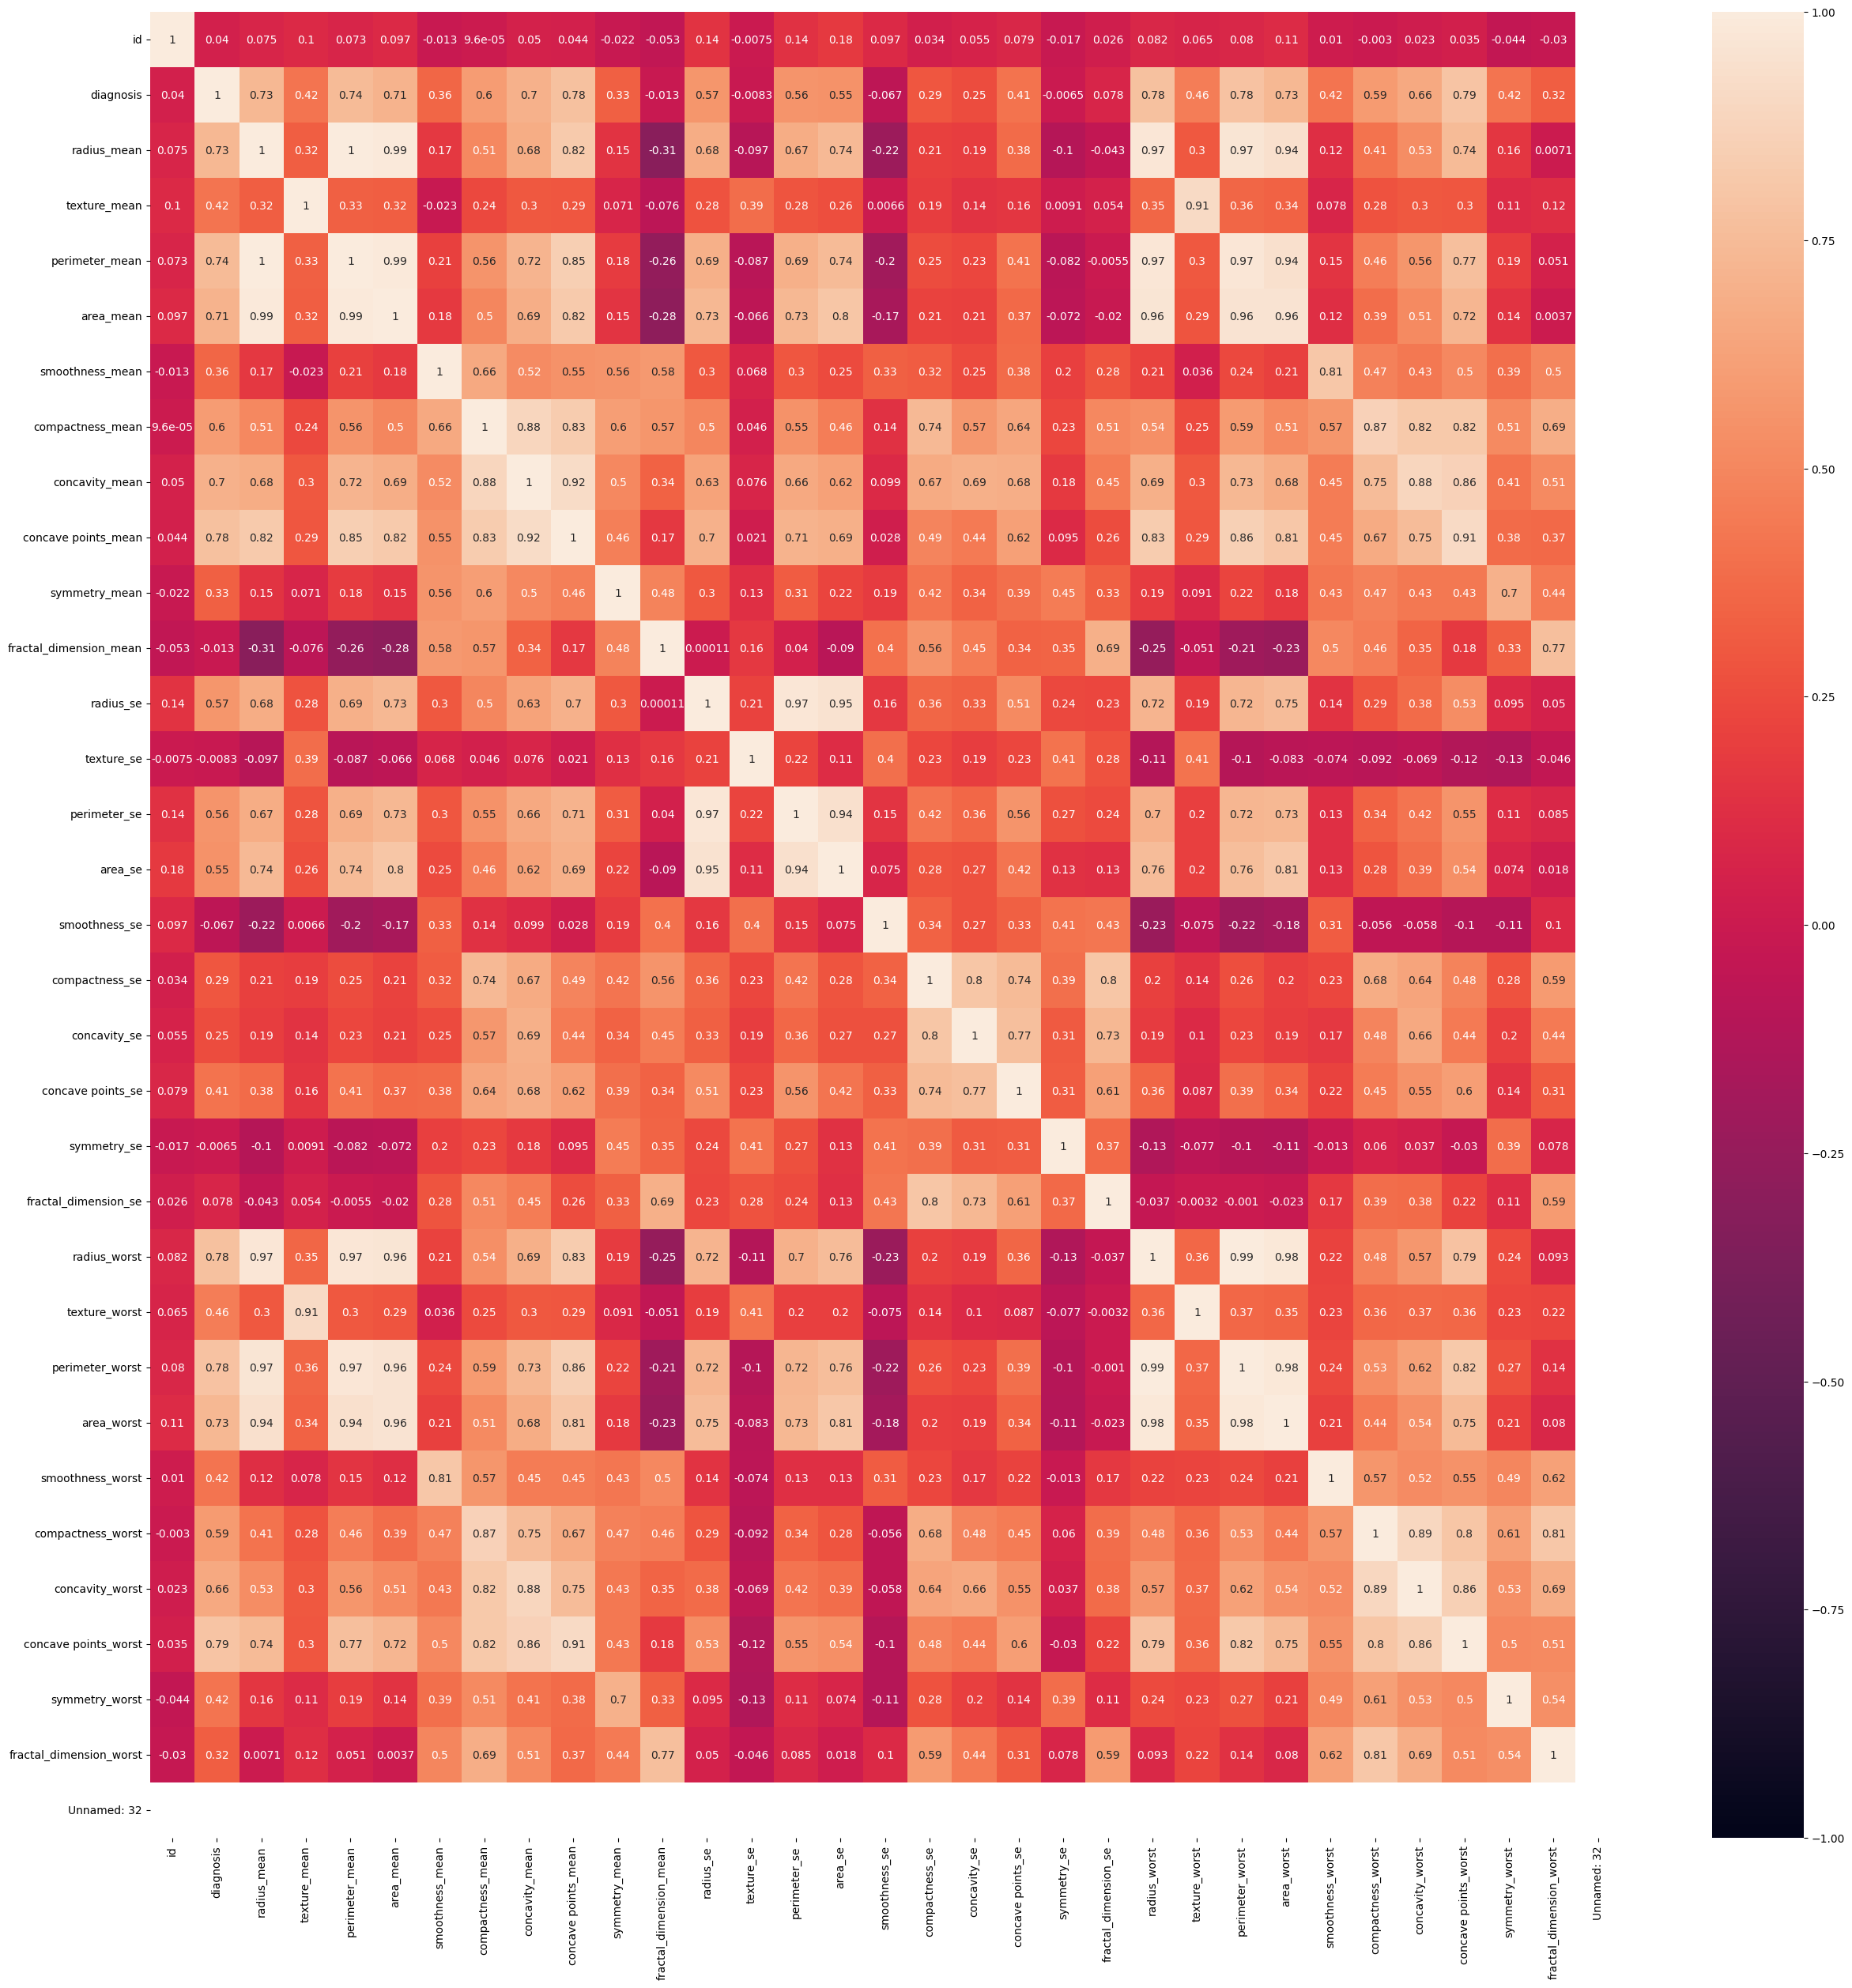

In [ ]:
plt.figure(figsize =(30,30))
sns.heatmap(df.corr(), vmin=-1, vmax=1, annot=True)
plt.show()

In [ ]:
!pip install scikit-learn

In [ ]:
import sklearn as sk
from sklearn.model_selection import train_test_split

y = df['diagnosis']
x = df.drop('diagnosis', axis=1)

In [ ]:
y.head()

,diagnosis
0,1
1,1
2,1
3,1
4,1


In [ ]:
x_test, x_train, y_test, y_train =  train_test_split(
    x, y, test_size=0.20, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
clf = DecisionTreeClassifier(random_state=1)

In [ ]:
clf.fit(x_train, y_train)

DecisionTreeClassifier(random_state=1)

In [ ]:
y_pred = clf.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.8857142857142857


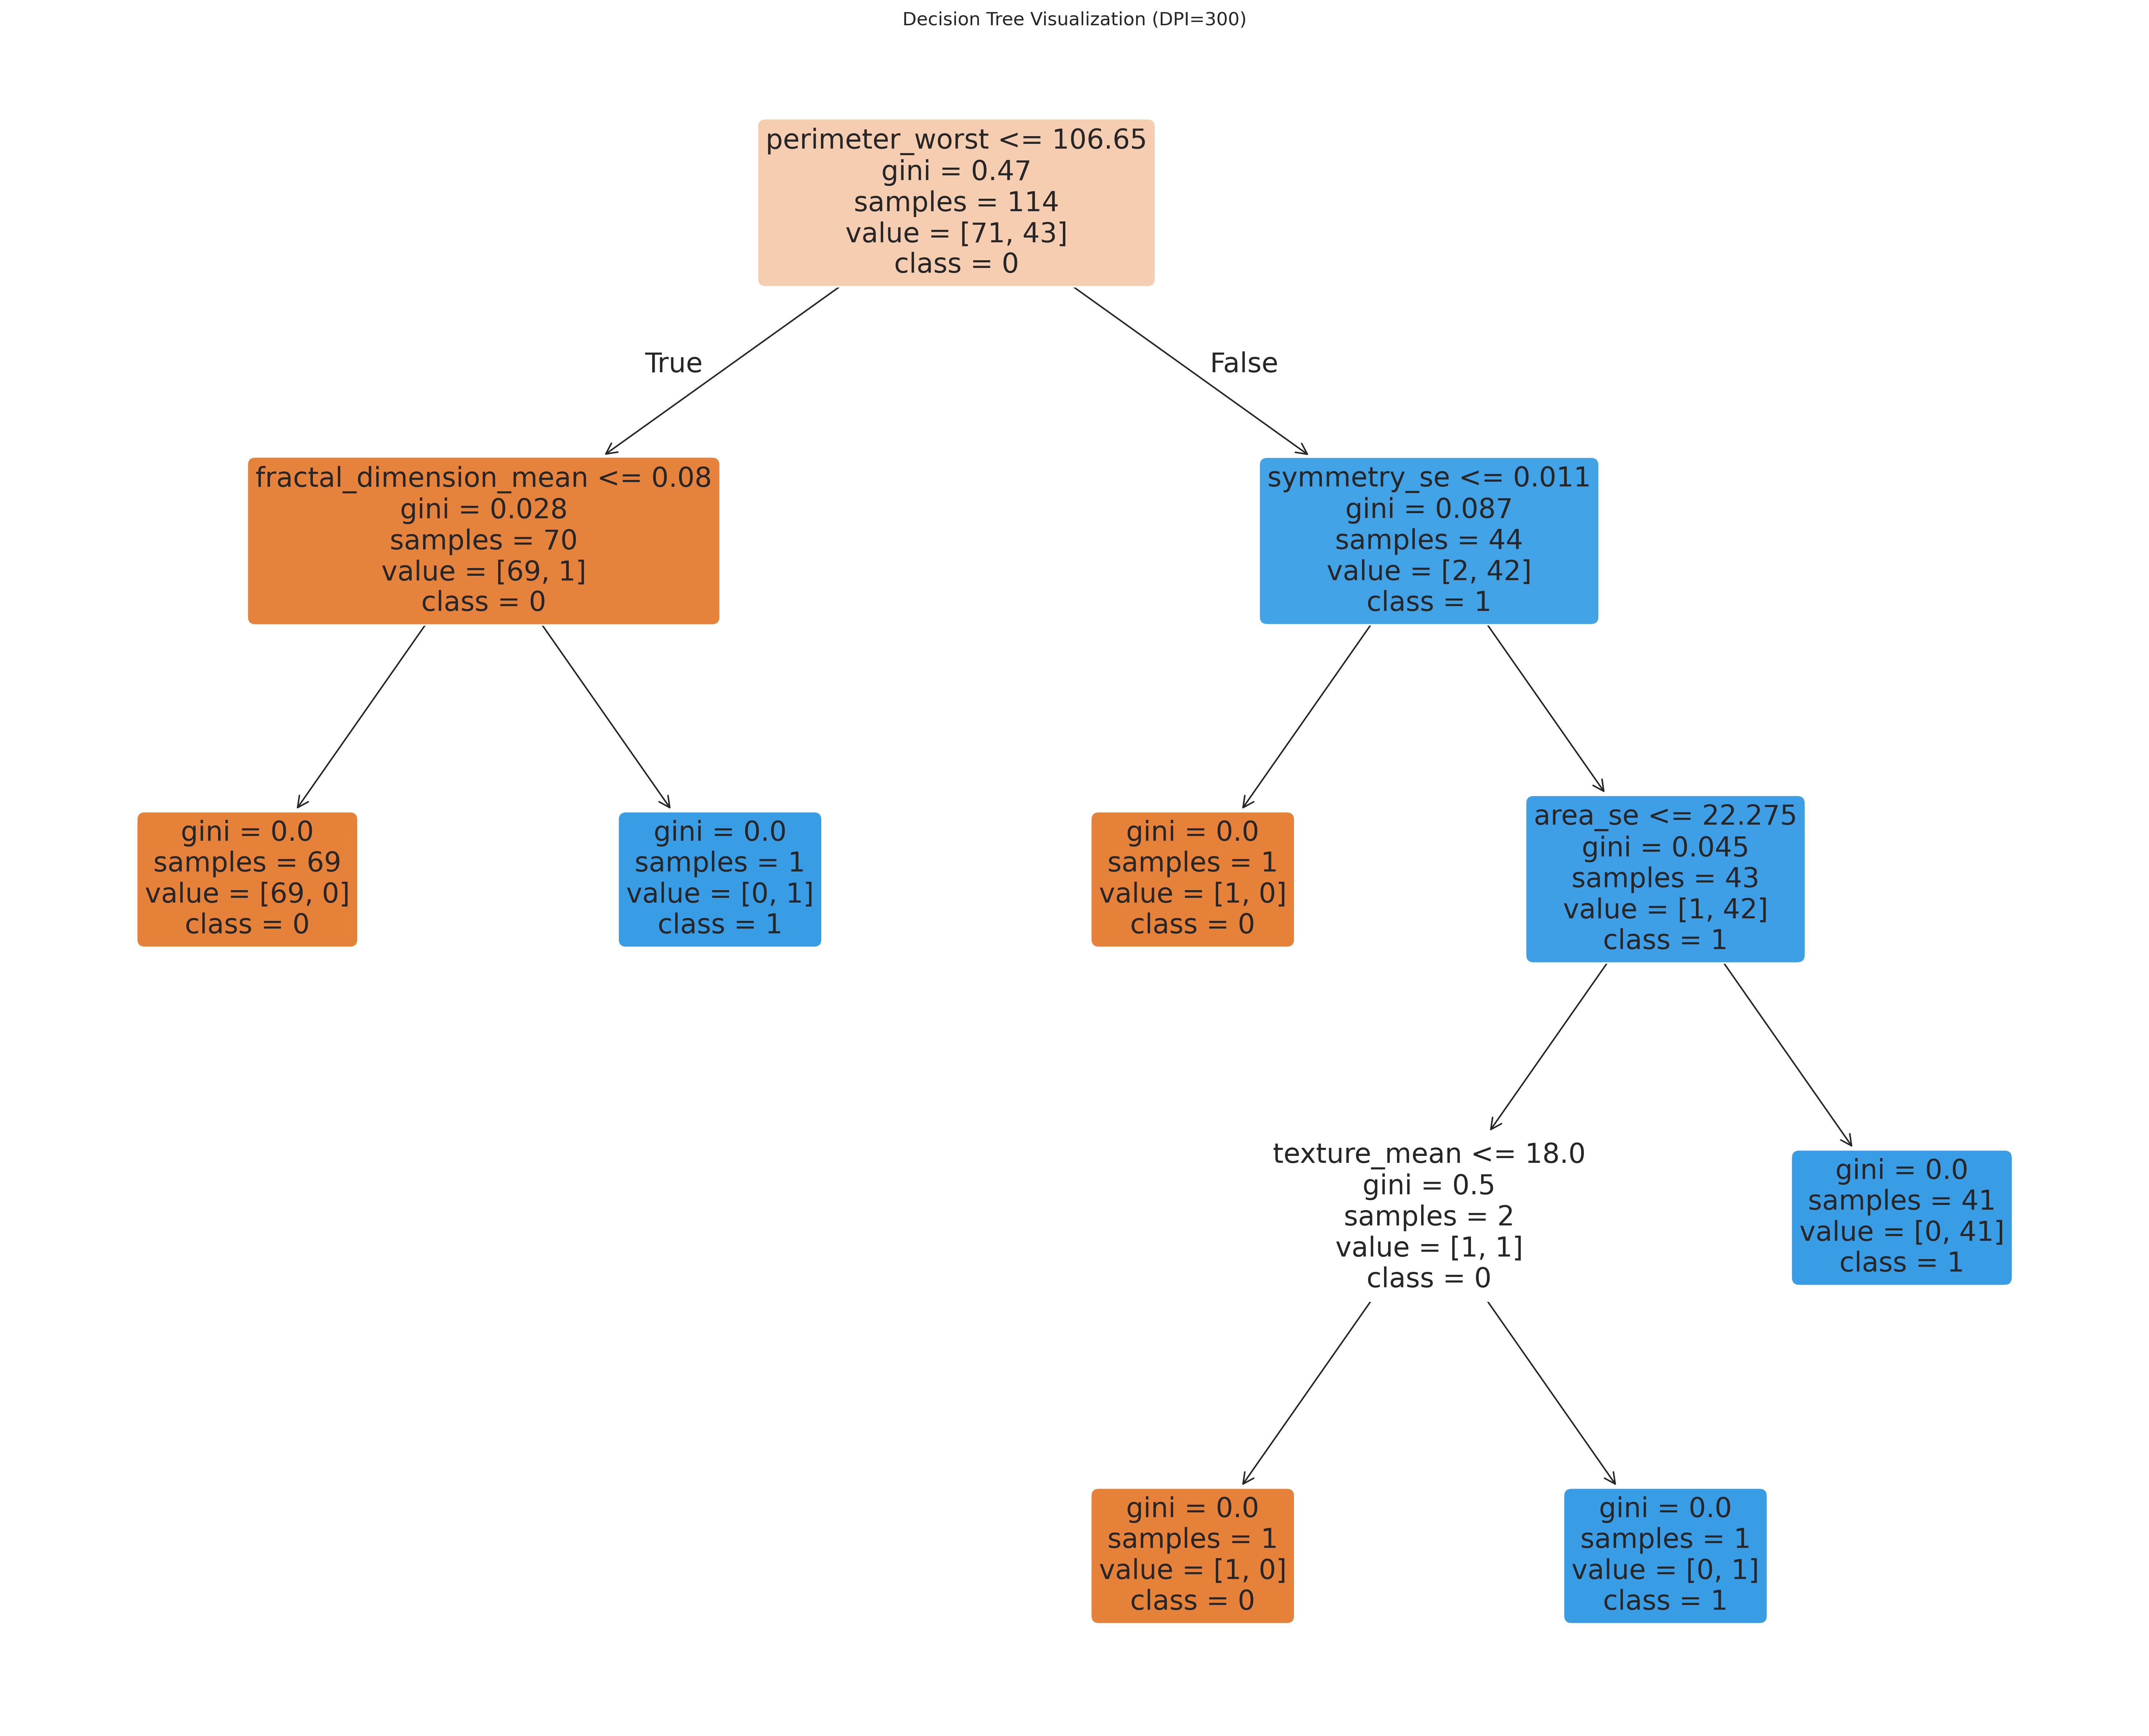

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_clf = clf

plt.figure(figsize=(25, 20), dpi=300) # Increased figure size and set DPI for display
plot_tree(tree_clf, filled=True, feature_names=x_train.columns,
          class_names=[str(c) for c in y_train.unique()], rounded=True)
plt.title("Decision Tree Visualization (DPI=300)")
plt.savefig("decision_tree_300dpi.png", dpi=300) # Save the figure with 300 DPI
plt.show()